# Model Evaluation Outputs

This file contains the relevant evaluation outputs with regards to our methods. We have generated the outputs from the evaluation here as our codebase comprises of methods using various python files, where we would save the plots from individual evaluation scripts. Placing them all in this notebook provides a clean an presentable format for our submission to showcase the evaluation results of our methods.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
)

### TF-IDF + Logistic Regression

TF-IDF + LR Combined model on Restaurant+Laptop
Ground truth source: combined_plus_laptop_test
Misclassification rows matched to ground truth: 100.00% (290 rows)
              precision    recall  f1-score   support

    positive     0.8416    0.7532    0.7949       543
    negative     0.5576    0.7045    0.6225       220
     neutral     0.5000    0.4972    0.4986       179

    accuracy                         0.6932       942
   macro avg     0.6330    0.6517    0.6387       942
weighted avg     0.7103    0.6932    0.6984       942

Macro F1: 0.6387
Accuracy: 0.6932


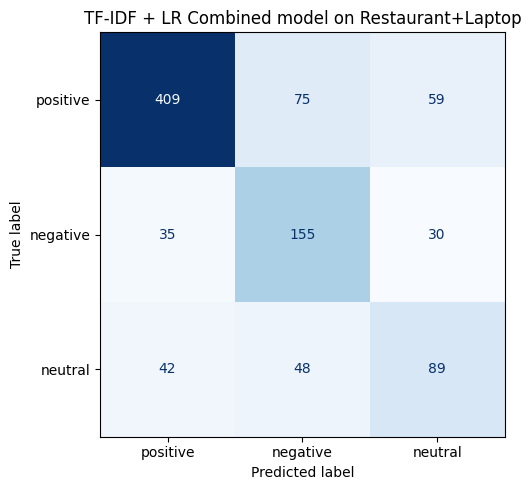

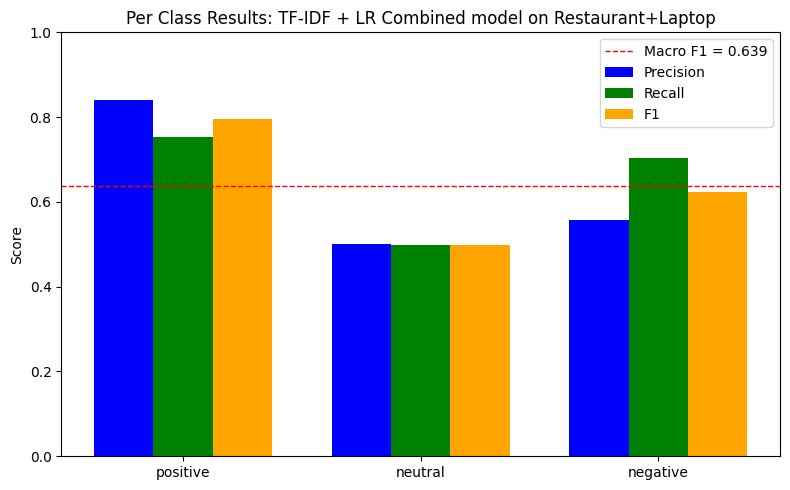

TF-IDF + LR Combined model on Restaurant
Ground truth source: combined_test
Misclassification rows matched to ground truth: 100.00% (208 rows)
              precision    recall  f1-score   support

    positive     0.8514    0.7788    0.8135       434
    negative     0.5060    0.6316    0.5619       133
     neutral     0.5037    0.5191    0.5113       131

    accuracy                         0.7020       698
   macro avg     0.6204    0.6432    0.6289       698
weighted avg     0.7203    0.7020    0.7088       698

Macro F1: 0.6289
Accuracy: 0.7020


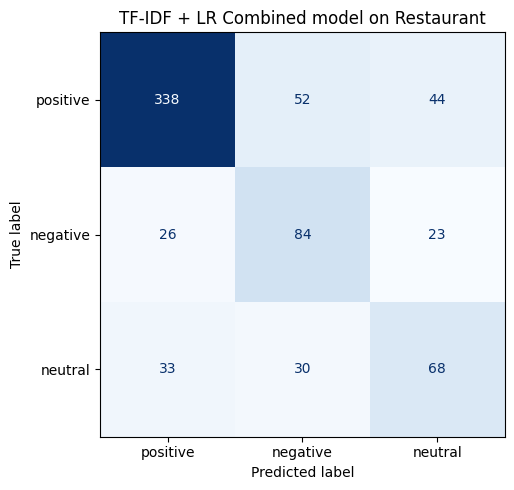

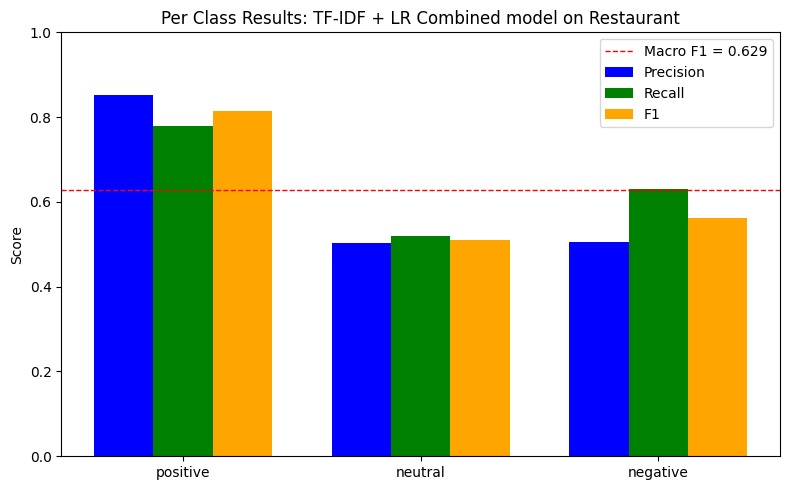

TF-IDF + LR Restaurant model on Laptop
Ground truth source: laptop_test
Misclassification rows matched to ground truth: 100.00% (73 rows)
              precision    recall  f1-score   support

    positive     0.7568    0.7706    0.7636       109
    negative     0.6415    0.7816    0.7047        87
     neutral     0.7407    0.4167    0.5333        48

    accuracy                         0.7049       244
   macro avg     0.7130    0.6563    0.6672       244
weighted avg     0.7125    0.7049    0.6973       244

Macro F1: 0.6672
Accuracy: 0.7049


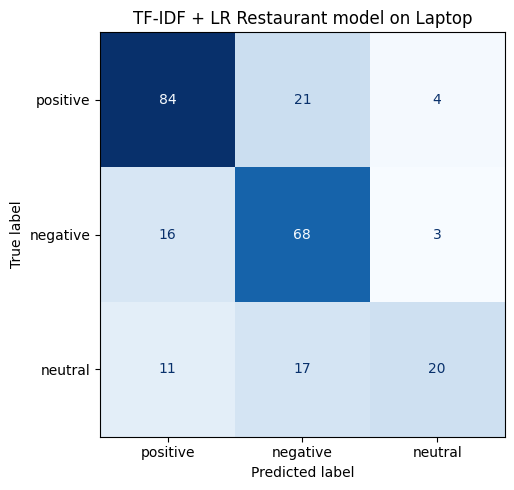

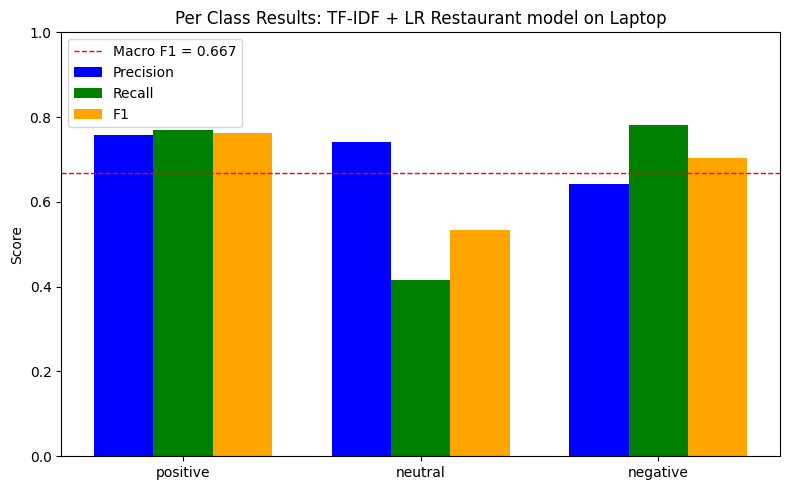

TF-IDF + LR Restaurant model on Restaurant
Ground truth source: combined_test
Misclassification rows matched to ground truth: 100.00% (221 rows)
              precision    recall  f1-score   support

    positive     0.8479    0.7581    0.8005       434
    negative     0.4590    0.6316    0.5316       133
     neutral     0.5039    0.4885    0.4961       131

    accuracy                         0.6834       698
   macro avg     0.6036    0.6261    0.6094       698
weighted avg     0.7093    0.6834    0.6921       698

Macro F1: 0.6094
Accuracy: 0.6834


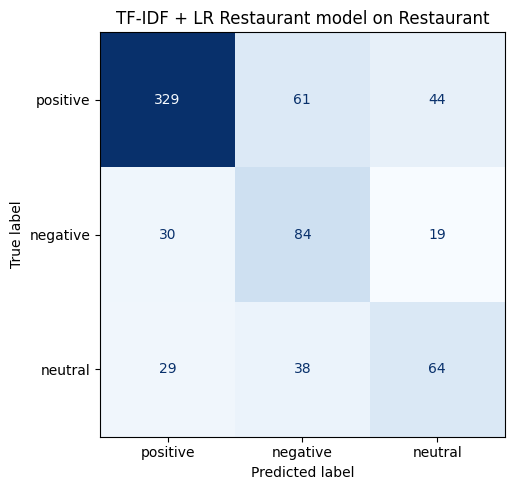

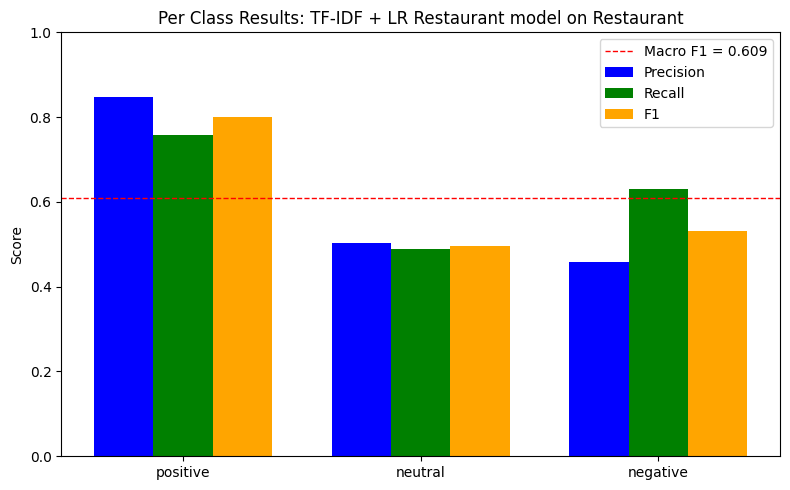

In [8]:
LABELS = ["positive", "negative", "neutral"]

TFIDF_LR_EVALS = {
    "Combined model on Restaurant+Laptop": "combined_model_on_rest_laptop_misclassifications.csv",
    "Combined model on Restaurant": "combined_model_on_rest_misclassifications.csv",
    "Restaurant model on Laptop": "rest_model_on_laptop_misclassifications.csv",
    "Restaurant model on Restaurant": "rest_model_on_rest_misclassifications.csv",
}

GROUND_TRUTH_POOLS = {
    "combined_test": ["combined/test.csv"],
    "laptop_test": ["laptop/processed/test.csv"],
    "combined_plus_laptop_test": ["combined/test.csv", "laptop/processed/test.csv"],
}


def _normalize_text(series):
    return series.astype(str).str.strip().str.lower()


def _normalize_sentiment(series):
    return _normalize_text(series)


def _find_column(df, candidates, kind, source_name):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"{source_name} is missing {kind} column. Tried: {candidates}")


def _add_occurrence_index(df):
    keys = ["__sid", "__text_norm", "__target_norm"]
    out = df.copy()
    out["__occ"] = out.groupby(keys).cumcount()
    return out


def _load_ground_truth_pool(csv_paths):
    parts = []
    for p in csv_paths:
        gt = pd.read_csv(p)
        gt_col = _find_column(gt, ["polarity", "true_sentiment", "ground_truth"], "ground-truth sentiment", p)
        gt = gt.copy()
        gt["__true"] = _normalize_sentiment(gt[gt_col])
        gt["__text_norm"] = _normalize_text(gt["text"])
        gt["__target_norm"] = _normalize_text(gt["target"])
        gt["__sid"] = gt["sentence_id"].astype(str).str.strip()
        gt = gt[gt["__true"].isin(LABELS)]
        gt = _add_occurrence_index(gt)
        parts.append(gt)

    if not parts:
        return pd.DataFrame()

    all_gt = pd.concat(parts, ignore_index=True)
    return all_gt


def _normalize_misclass_df(mis, source_name):
    true_col = _find_column(
        mis,
        ["polarity", "true_sentiment", "ground_truth", "label"],
        "ground-truth sentiment",
        source_name,
    )
    pred_col = _find_column(
        mis,
        ["ML", "prediction", "predicted_sentiment", "model_prediction"],
        "predicted sentiment",
        source_name,
    )

    mis = mis.copy()
    mis["__true"] = _normalize_sentiment(mis[true_col])
    mis["__pred"] = _normalize_sentiment(mis[pred_col])
    mis["__text_norm"] = _normalize_text(mis["text"])
    mis["__target_norm"] = _normalize_text(mis["target"])
    mis["__sid"] = mis["sentence_id"].astype(str).str.strip()
    mis = mis[mis["__true"].isin(LABELS) & mis["__pred"].isin(LABELS)]
    mis = _add_occurrence_index(mis)
    return mis


def _match_ratio(mis_norm, gt_norm):
    if len(mis_norm) == 0 or len(gt_norm) == 0:
        return 0.0

    keys = ["__sid", "__text_norm", "__target_norm", "__occ"]
    matched = mis_norm[keys].merge(gt_norm[keys], on=keys, how="inner")
    return len(matched) / len(mis_norm)


def _choose_best_ground_truth_pool(mis_norm):
    best_name = None
    best_gt = None
    best_ratio = -1.0

    for pool_name, paths in GROUND_TRUTH_POOLS.items():
        gt_pool = _load_ground_truth_pool(paths)
        ratio = _match_ratio(mis_norm, gt_pool)
        if ratio > best_ratio:
            best_name, best_gt, best_ratio = pool_name, gt_pool, ratio

    return best_name, best_gt, best_ratio


def _reconstruct_full_predictions(gt_pool, mis_norm):
    full_eval = gt_pool[["__sid", "__text_norm", "__target_norm", "__occ", "__true"]].copy()
    full_eval["__pred"] = full_eval["__true"]

    keys = ["__sid", "__text_norm", "__target_norm", "__occ"]
    mis_pred = mis_norm[keys + ["__pred"]].copy()

    merged = full_eval.merge(mis_pred, on=keys, how="left", suffixes=("", "_mis"))
    merged["__pred"] = merged["__pred_mis"].fillna(merged["__pred"])
    merged = merged.drop(columns=["__pred_mis"])
    return merged


def evaluate_tfidf_lr(csv_file, name):
    mis_raw = pd.read_csv(csv_file)
    mis_norm = _normalize_misclass_df(mis_raw, csv_file)

    pool_name, gt_pool, coverage = _choose_best_ground_truth_pool(mis_norm)
    full = _reconstruct_full_predictions(gt_pool, mis_norm)

    print(f"{name}")
    print(f"Ground truth source: {pool_name}")
    print(f"Misclassification rows matched to ground truth: {coverage:.2%} ({len(mis_norm)} rows)")

    results = classification_report(
        full["__true"],
        full["__pred"],
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    print(
        classification_report(
            full["__true"],
            full["__pred"],
            labels=LABELS,
            digits=4,
            zero_division=0,
        )
    )
    print(f"Macro F1: {results['macro avg']['f1-score']:.4f}")
    print(f"Accuracy: {(full['__true'] == full['__pred']).mean():.4f}")

    cm = confusion_matrix(full["__true"], full["__pred"], labels=LABELS)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    plot_order = ["positive", "neutral", "negative"]
    x, w = np.arange(len(plot_order)), 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w, [results[l]["precision"] for l in plot_order], w, label="Precision", color="blue")
    ax.bar(x, [results[l]["recall"] for l in plot_order], w, label="Recall", color="green")
    ax.bar(x + w, [results[l]["f1-score"] for l in plot_order], w, label="F1", color="orange")
    ax.axhline(
        results["macro avg"]["f1-score"],
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Macro F1 = {results['macro avg']['f1-score']:.3f}",
    )
    ax.set_title(f"Per Class Results: {name}")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_order)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()


for model_name, csv_path in TFIDF_LR_EVALS.items():
    evaluate_tfidf_lr(csv_path, f"TF-IDF + LR {model_name}")

### Bert Uncased

BERT Restaurant
              precision    recall  f1-score   support

    positive     0.9133    0.8986    0.9059       434
    negative     0.6875    0.7444    0.7148       133
     neutral     0.5984    0.5802    0.5891       131

    accuracy                         0.8095       698
   macro avg     0.7331    0.7410    0.7366       698
weighted avg     0.8112    0.8095    0.8101       698

Macro F1: 0.7366
Accuracy: 0.8095


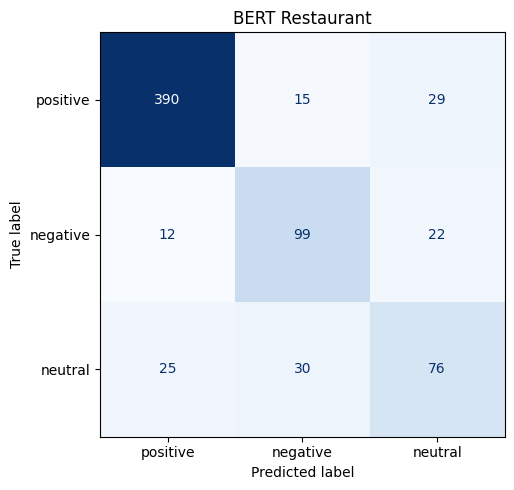

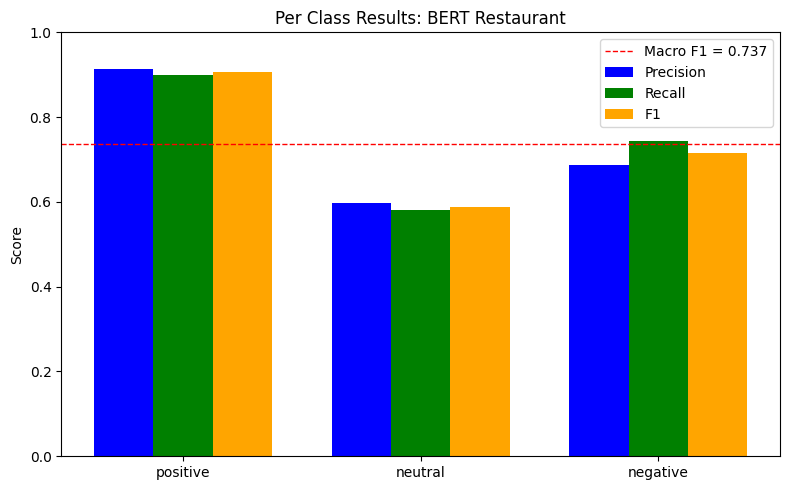

BERT Laptop
              precision    recall  f1-score   support

    positive     0.9072    0.8073    0.8544       109
    negative     0.8293    0.7816    0.8047        87
     neutral     0.5538    0.7500    0.6372        48

    accuracy                         0.7869       244
   macro avg     0.7634    0.7796    0.7654       244
weighted avg     0.8099    0.7869    0.7939       244

Macro F1: 0.7654
Accuracy: 0.7869


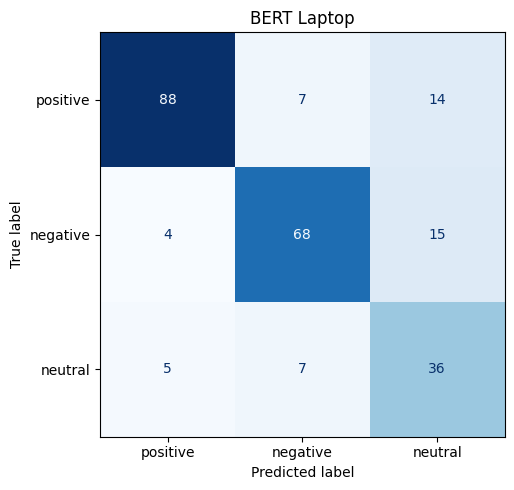

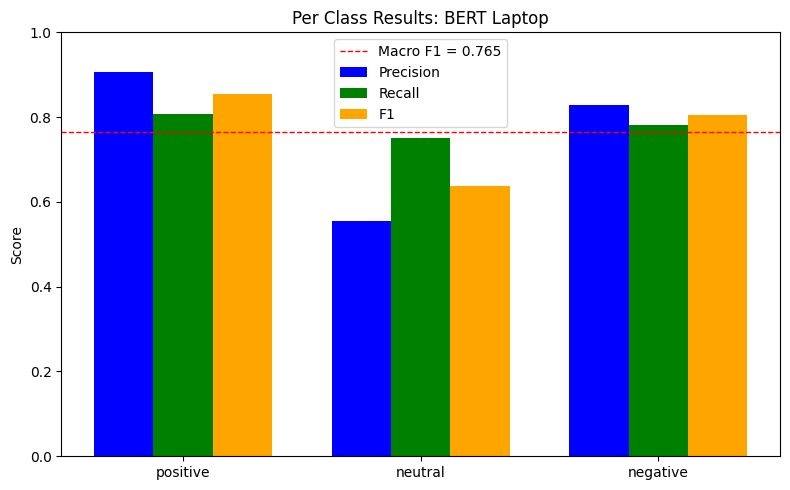

In [2]:
LABELS = ["positive", "negative", "neutral"]


def evaluate_bert(csv_file, name):
    df = pd.read_csv(csv_file)

    valid = df.copy()
    valid["true_sentiment"] = valid["true_sentiment"].astype(str).str.strip().str.lower()
    valid["predicted_sentiment"] = valid["predicted_sentiment"].astype(str).str.strip().str.lower()
    valid = valid[valid["predicted_sentiment"].isin(LABELS) & valid["true_sentiment"].isin(LABELS)]
    
    # print classification results
    print(f"{name}")
    results = classification_report(
        valid["true_sentiment"],
        valid["predicted_sentiment"],
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    print(
        classification_report(
            valid["true_sentiment"],
            valid["predicted_sentiment"],
            labels=LABELS,
            digits=4,
            zero_division=0,
        )
    )
    print(f"Macro F1: {results['macro avg']['f1-score']:.4f}")
    print(f"Accuracy: {(valid['true_sentiment'] == valid['predicted_sentiment']).mean():.4f}")

    # plot confusion matrix
    cm = confusion_matrix(valid["true_sentiment"], valid["predicted_sentiment"], labels=LABELS)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    # plot chart results for each class
    plot_order = ["positive", "neutral", "negative"]
    x, w = np.arange(len(plot_order)), 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w, [results[l]["precision"] for l in plot_order], w, label="Precision", color="blue")
    ax.bar(x, [results[l]["recall"] for l in plot_order], w, label="Recall", color="green")
    ax.bar(x + w, [results[l]["f1-score"] for l in plot_order], w, label="F1", color="orange")
    ax.axhline(
        results["macro avg"]["f1-score"],
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Macro F1 = {results['macro avg']['f1-score']:.3f}",
    )
    ax.set_title(f"Per Class Results: {name}")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_order)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()


BERT_EVALS = {
    "Restaurant": "models/bert/experiments/restaurants_finetuned/restaurants/v2/predictions.csv",
    "Laptop": "models/bert/experiments/laptop_finetuned/predictions.csv",
}

for model_name, csv_path in BERT_EVALS.items():
    evaluate_bert(csv_path, f"BERT {model_name}")

### Qwen 2.5

Qwen Baseline
              precision    recall  f1-score   support

    positive     0.7958    0.9700    0.8744       434
    negative     0.7450    0.8346    0.7872       133
     neutral     0.6500    0.0992    0.1722       131

    accuracy                         0.7808       698
   macro avg     0.7303    0.6346    0.6113       698
weighted avg     0.7588    0.7808    0.7260       698

Macro F1: 0.6113
Accuracy: 0.7808


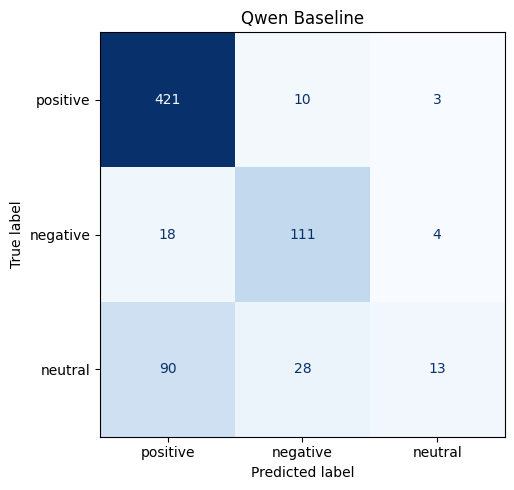

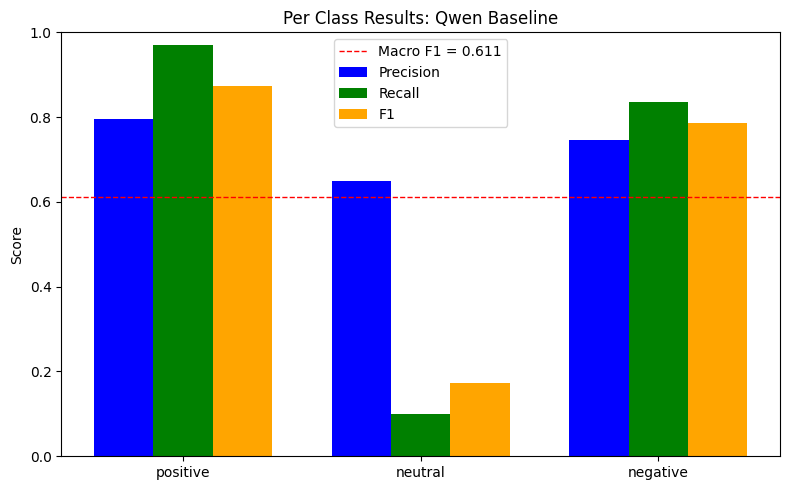

Qwen LoRA Restaurant
              precision    recall  f1-score   support

    positive     0.9688    0.7166    0.8238       434
    negative     0.7076    0.9098    0.7961       133
     neutral     0.4272    0.6718    0.5223       131

    accuracy                         0.7450       698
   macro avg     0.7012    0.7660    0.7140       698
weighted avg     0.8174    0.7450    0.7619       698

Macro F1: 0.7140
Accuracy: 0.7450


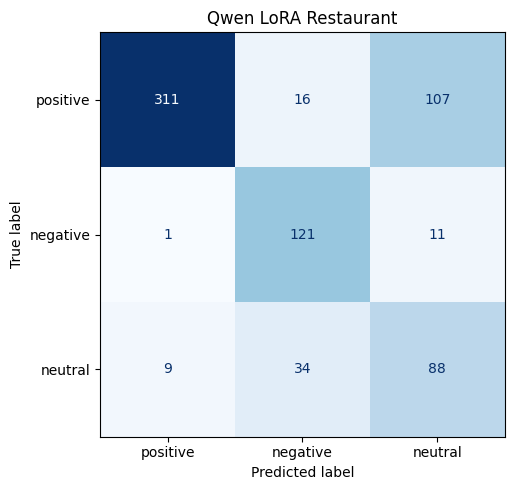

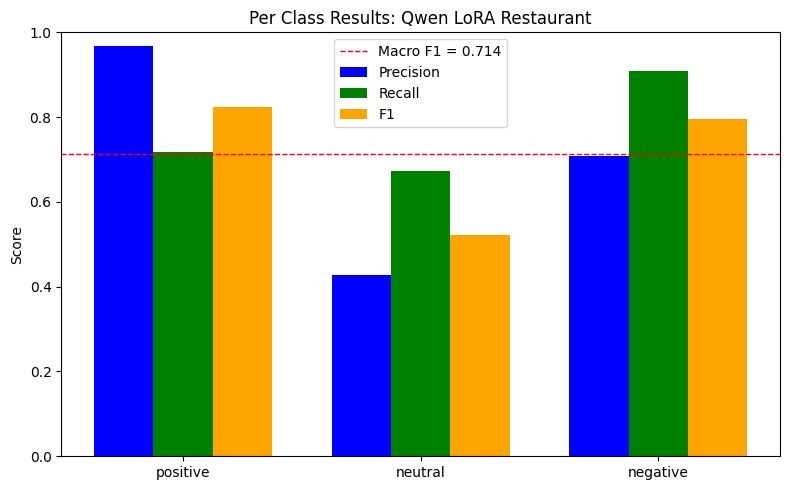

Qwen LoRA Both
              precision    recall  f1-score   support

    positive     0.9071    0.8548    0.8802       434
    negative     0.7500    0.8346    0.7900       133
     neutral     0.5319    0.5725    0.5515       131

    accuracy                         0.7980       698
   macro avg     0.7297    0.7540    0.7406       698
weighted avg     0.8067    0.7980    0.8013       698

Macro F1: 0.7406
Accuracy: 0.7980


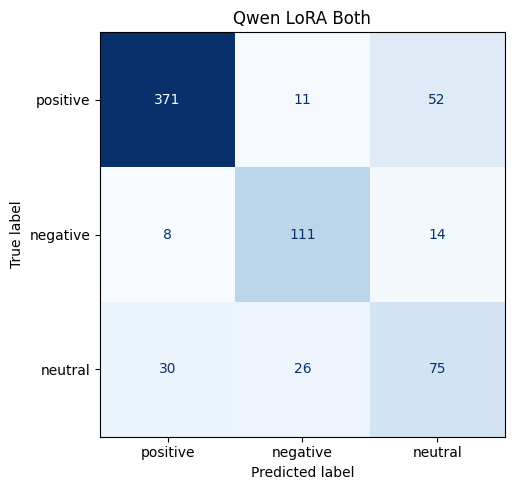

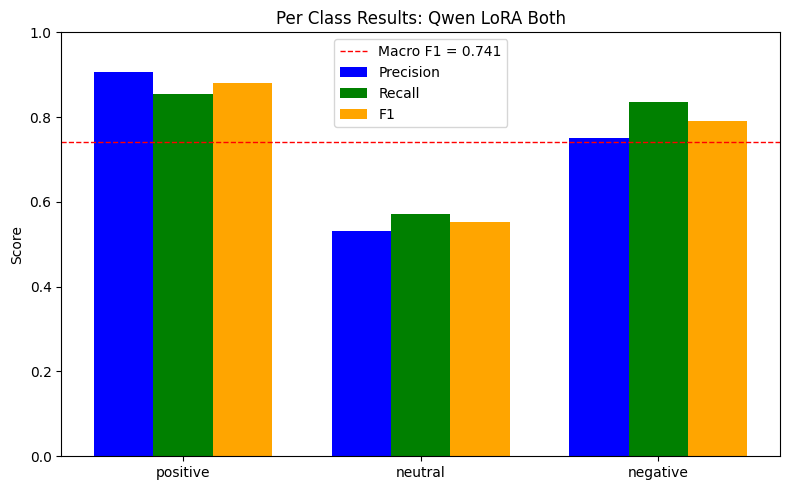

In [9]:
LABELS = ["positive", "negative", "neutral"]


def evaluate_qwen(csv_file, name):
    df = pd.read_csv(csv_file)

    # Support both naming styles used across evaluation exports.
    if {"ground_truth", "prediction"}.issubset(df.columns):
        true_col, pred_col = "ground_truth", "prediction"
    elif {"true_sentiment", "predicted_sentiment"}.issubset(df.columns):
        true_col, pred_col = "true_sentiment", "predicted_sentiment"
    else:
        raise ValueError(
            f"{csv_file} is missing sentiment columns. "
            "Need either (ground_truth, prediction) or (true_sentiment, predicted_sentiment)."
        )

    valid = df.copy()
    valid[true_col] = valid[true_col].astype(str).str.strip().str.lower()
    valid[pred_col] = valid[pred_col].astype(str).str.strip().str.lower()
    valid = valid[valid[pred_col].isin(LABELS) & valid[true_col].isin(LABELS)]

    print(f"{name}")
    results = classification_report(
        valid[true_col],
        valid[pred_col],
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
    print(
        classification_report(
            valid[true_col],
            valid[pred_col],
            labels=LABELS,
            digits=4,
            zero_division=0,
        )
    )
    print(f"Macro F1: {results['macro avg']['f1-score']:.4f}")
    print(f"Accuracy: {(valid[true_col] == valid[pred_col]).mean():.4f}")

    cm = confusion_matrix(valid[true_col], valid[pred_col], labels=LABELS)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    plot_order = ["positive", "neutral", "negative"]
    x, w = np.arange(len(plot_order)), 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w, [results[l]["precision"] for l in plot_order], w, label="Precision", color="blue")
    ax.bar(x, [results[l]["recall"] for l in plot_order], w, label="Recall", color="green")
    ax.bar(x + w, [results[l]["f1-score"] for l in plot_order], w, label="F1", color="orange")
    ax.axhline(
        results["macro avg"]["f1-score"],
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Macro F1 = {results['macro avg']['f1-score']:.3f}",
    )
    ax.set_title(f"Per Class Results: {name}")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_order)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()


QWEN_EVALS = {
    "Baseline": "result/baseline/combined_predictions.csv",
    "LoRA Restaurant": "result/lora_restaurant/combined_predictions.csv",
    "LoRA Both": "result/lora_both/combined_predictions.csv",
}

for model_name, csv_path in QWEN_EVALS.items():
    evaluate_qwen(csv_path, f"Qwen {model_name}")

### Chain Of Thought (GPT-5.4-mini)

Baseline Restaurant
              precision    recall  f1-score   support

    positive     0.8747    0.9654    0.9179       434
    negative     0.8560    0.8045    0.8295       133
     neutral     0.6774    0.4846    0.5650       130

    accuracy                         0.8451       697
   macro avg     0.8027    0.7515    0.7708       697
weighted avg     0.8344    0.8451    0.8352       697

Macro F1: 0.7708
Accuracy: 0.8451


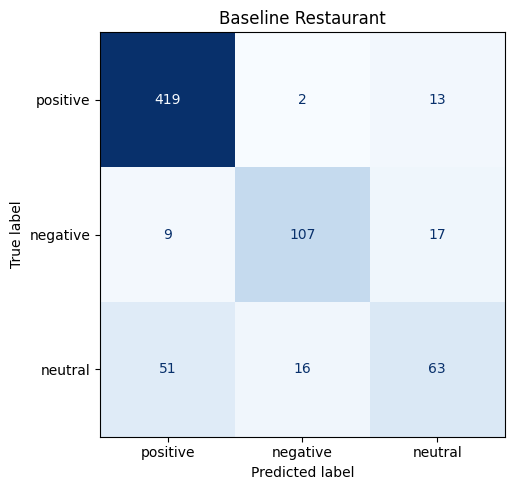

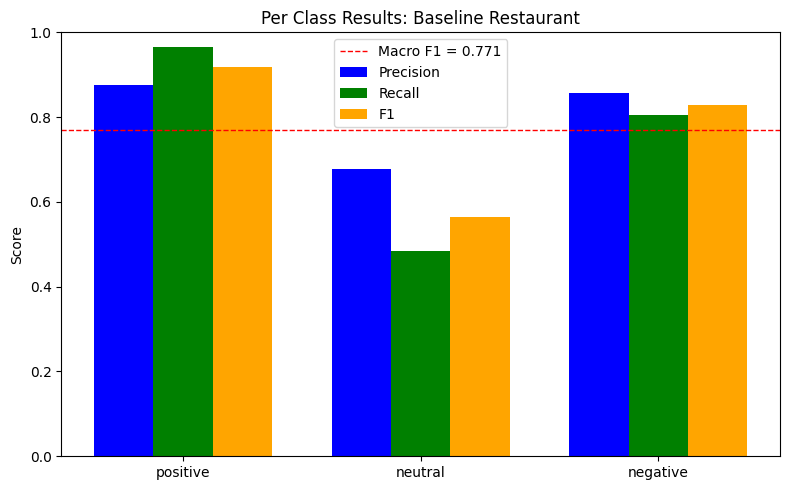

CoT Restaurant
              precision    recall  f1-score   support

    positive     0.8855    0.9447    0.9142       434
    negative     0.7877    0.8647    0.8244       133
     neutral     0.6742    0.4580    0.5455       131

    accuracy                         0.8381       698
   macro avg     0.7825    0.7558    0.7613       698
weighted avg     0.8272    0.8381    0.8279       698

Macro F1: 0.7613
Accuracy: 0.8381


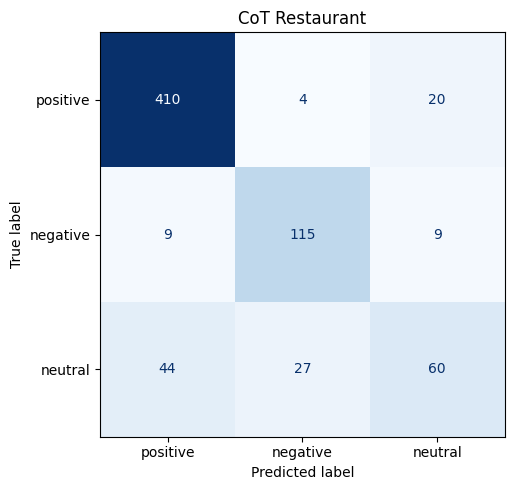

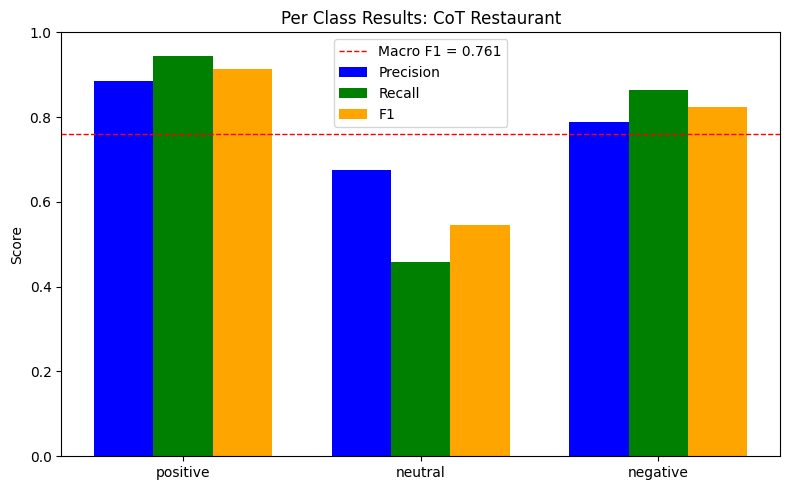

Baseline Laptop
              precision    recall  f1-score   support

    positive     0.8843    0.9817    0.9304       109
    negative     0.8989    0.9195    0.9091        87
     neutral     0.8235    0.5833    0.6829        48

    accuracy                         0.8811       244
   macro avg     0.8689    0.8282    0.8408       244
weighted avg     0.8775    0.8811    0.8741       244

Macro F1: 0.8408
Accuracy: 0.8811


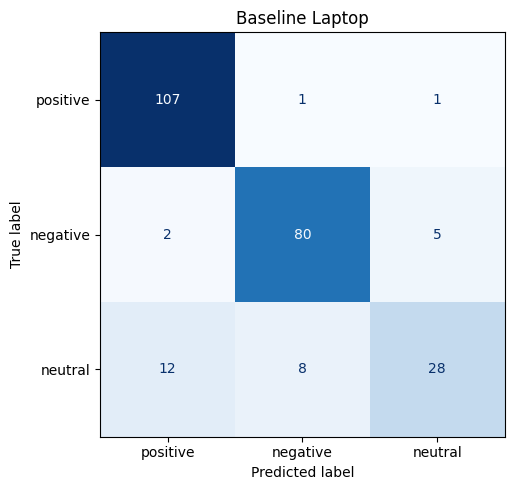

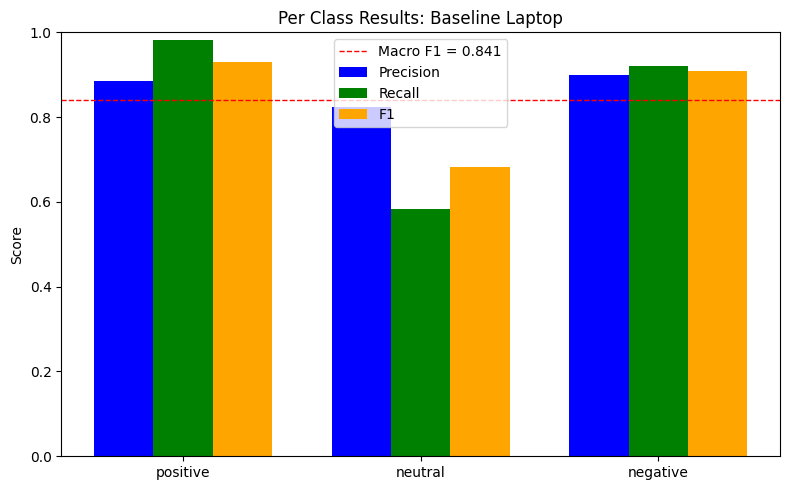

CoT Laptop
              precision    recall  f1-score   support

    positive     0.9182    0.9266    0.9224       109
    negative     0.8454    0.9425    0.8913        87
     neutral     0.8108    0.6250    0.7059        48

    accuracy                         0.8730       244
   macro avg     0.8581    0.8314    0.8399       244
weighted avg     0.8711    0.8730    0.8687       244

Macro F1: 0.8399
Accuracy: 0.8730


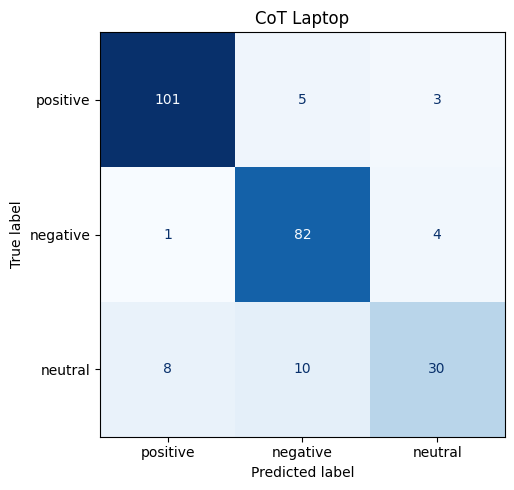

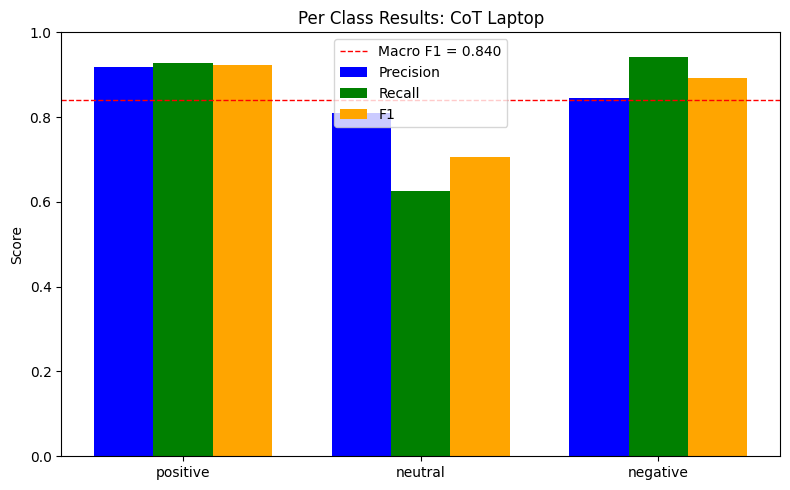

In [2]:
LABELS = ["positive", "negative", "neutral"]

def evaluate(csv_file, name):
    df = pd.read_csv(csv_file)
    valid = df[df["predicted_sentiment"] != "error"]

    # print classification results
    print(f"{name}")
    results = classification_report(
        valid["true_sentiment"], valid["predicted_sentiment"],
        labels=LABELS, output_dict=True, zero_division=0
    )
    print(classification_report(
        valid["true_sentiment"], valid["predicted_sentiment"],
        labels=LABELS, digits=4, zero_division=0
    ))
    print(f"Macro F1: {results['macro avg']['f1-score']:.4f}")
    print(f"Accuracy: {valid['correct'].mean():.4f}")

    # plot the confusion matrix
    cm = confusion_matrix(valid["true_sentiment"], valid["predicted_sentiment"], labels=LABELS)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}")
    plt.tight_layout(); plt.show()

    # plot charts for results for each class
    plot_order = ["positive", "neutral", "negative"]
    x, w = np.arange(len(plot_order)), 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w, [results[l]["precision"] for l in plot_order], w, label="Precision", color="blue")
    ax.bar(x, [results[l]["recall"] for l in plot_order], w, label="Recall", color="green")
    ax.bar(x + w, [results[l]["f1-score"] for l in plot_order], w, label="F1", color="orange")
    ax.axhline(results["macro avg"]["f1-score"], color="red", linestyle="--", linewidth=1, label=f"Macro F1 = {results['macro avg']['f1-score']:.3f}")
    ax.set_title(f"Per Class Results: {name}")
    ax.set_xticks(x); ax.set_xticklabels(plot_order)
    ax.set_ylabel("Score"); ax.set_ylim(0, 1); ax.legend()
    plt.tight_layout(); plt.show()

evaluate("results_baseline_restaurant.csv", "Baseline Restaurant")
evaluate("results_cot_restaurant.csv", "CoT Restaurant")
evaluate("results_baseline_laptop.csv", "Baseline Laptop")
evaluate("results_cot_laptop.csv", "CoT Laptop")